# 01 — Data Loading & Exploration

Binary classification: **Transportation** (label 0) vs **Conversation** (label 1)

**UrbanSound8K classes used:**
- Transportation → `car_horn`, `engine_idling`, `siren`
- Conversation   → `children_playing`

**Custom data:**
- Transportation → `data/raw/transpotation/` (mp3 files)
- Conversation   → `data/raw/custom_audio/conversation/` (long WAV recordings)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from src.utils import get_urbansound_metadata, get_audio_file_path, load_audio

DATASET_PATH      = '../data/raw/UrbanSound8K'
CUSTOM_CONV_PATH  = '../data/raw/custom_audio/conversation'
CUSTOM_TRANS_PATH = '../data/raw/transpotation'
SAMPLE_RATE       = 22050

TRANSPORT_CLASSES    = {'car_horn', 'engine_idling', 'siren'}
CONVERSATION_CLASSES = {'children_playing'}

## 1. UrbanSound8K — filtered to binary classes

In [2]:
meta = get_urbansound_metadata(DATASET_PATH)
mask = meta['class'].isin(TRANSPORT_CLASSES | CONVERSATION_CLASSES)
df   = meta[mask].copy()
df['binary_label'] = df['class'].apply(
    lambda c: 'Transportation' if c in TRANSPORT_CLASSES else 'Conversation'
)
print(f'Total US8K clips used: {len(df)}')
print(df['class'].value_counts().to_string())
print()
print(df['binary_label'].value_counts().to_string())

Total US8K clips used: 3358
class
children_playing    1000
engine_idling       1000
siren                929
car_horn             429

binary_label
Transportation    2358
Conversation      1000


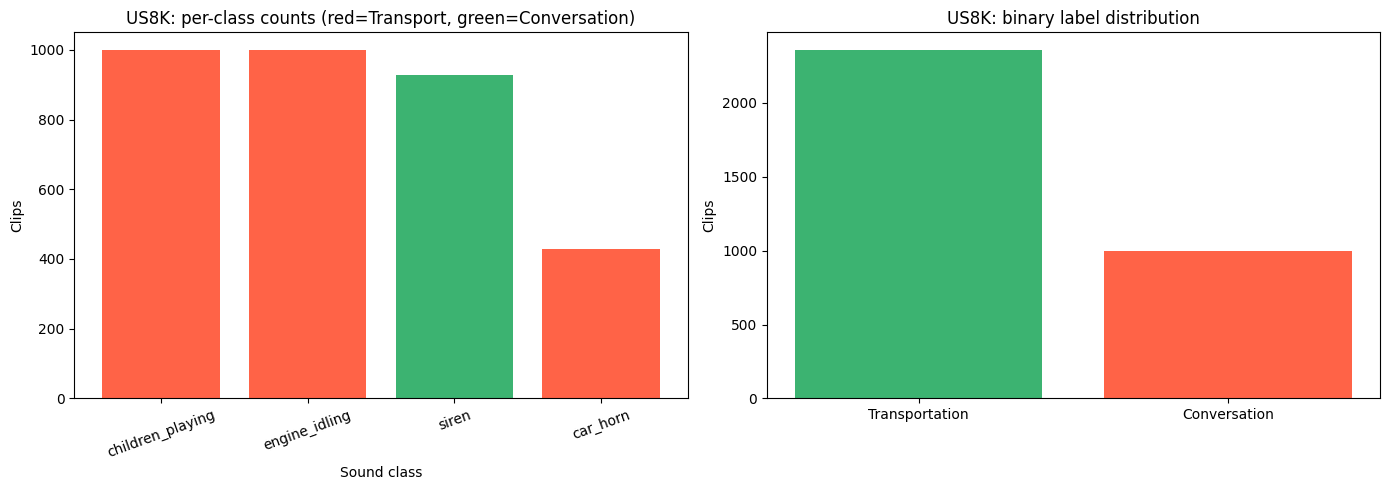

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values,
            color=['tomato','tomato','mediumseagreen','tomato'])
axes[0].set_title('US8K: per-class counts (red=Transport, green=Conversation)')
axes[0].set_xlabel('Sound class')
axes[0].set_ylabel('Clips')
axes[0].tick_params(axis='x', rotation=20)

label_counts = df['binary_label'].value_counts()
axes[1].bar(label_counts.index, label_counts.values,
            color=['mediumseagreen', 'tomato'])
axes[1].set_title('US8K: binary label distribution')
axes[1].set_ylabel('Clips')

plt.tight_layout()
plt.show()

## 2. Custom data overview

In [4]:
trans_files = [f for f in os.listdir(CUSTOM_TRANS_PATH)
               if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))]
print(f'Custom Transportation files: {len(trans_files)}')
for f in trans_files:
    size_mb = os.path.getsize(os.path.join(CUSTOM_TRANS_PATH, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Custom Transportation files: 26
  arunangshubanerjee-suburban-alley-traffic-ambience-359577.mp3  (0.8 MB)
  arunangshubanerjee-traffic-commotion-with-siren-and-car-horns-urban-street-noise-457233.mp3  (1.0 MB)
  dkfilms-highway-traffic-ambience-indian-sfx-library-266395.mp3  (2.0 MB)
  freesound_community-city-traffic-noise2-16695.mp3  (20.1 MB)
  freesound_community-continuous-traffic-19746.mp3  (16.0 MB)
  freesound_community-driving-by-noisy-car-33855.mp3  (0.5 MB)
  freesound_community-galle-road-51183.mp3  (5.3 MB)
  freesound_community-road-noise-1-72297.mp3  (1.7 MB)
  freesound_community-road-noise-2-59478.mp3  (4.4 MB)
  freesound_community-street-ambience-of-sri-lanka-29093.mp3  (1.1 MB)
  freesound_community-traffic-19979.mp3  (2.1 MB)
  freesound_community-traffic-construction1-35557.mp3  (0.7 MB)
  freesound_community-train-departure-72609.mp3  (1.3 MB)
  freesound_community-train-ella-kandy-30111.mp3  (1.0 MB)
  iqbalfirdaushasan-urban-traffic-noise-378409.mp3  (7.3 MB)
 

In [5]:
conv_files = [f for f in os.listdir(CUSTOM_CONV_PATH)
              if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))]
print(f'Custom Conversation files: {len(conv_files)}')
for f in conv_files:
    size_mb = os.path.getsize(os.path.join(CUSTOM_CONV_PATH, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Custom Conversation files: 2
  ES2008a.Mix-Headset.wav  (33.4 MB)
  ES2008b.Mix-Headset.wav  (71.4 MB)


## 3. Mel spectrogram examples
Comparing transportation vs conversation audio.

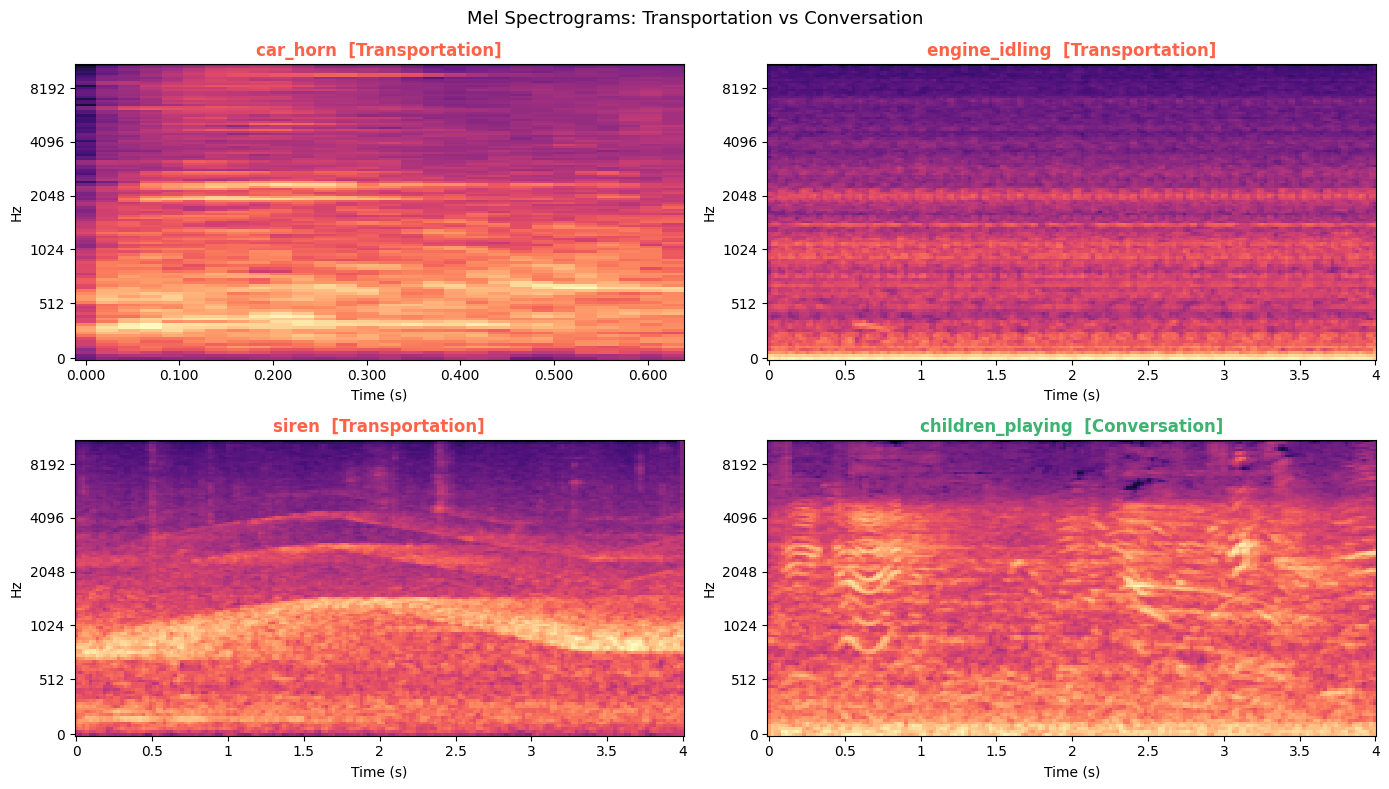

In [6]:
examples = [
    ('car_horn',        'Transportation', 'tomato'),
    ('engine_idling',   'Transportation', 'tomato'),
    ('siren',           'Transportation', 'tomato'),
    ('children_playing','Conversation',   'mediumseagreen'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (cls, group, color) in zip(axes, examples):
    sample = df[df['class'] == cls].iloc[0]
    fp = get_audio_file_path(DATASET_PATH, int(sample['fold']), sample['slice_file_name'])
    if not os.path.isfile(fp):
        ax.set_title(f'{cls} — file not found')
        continue
    audio, sr = load_audio(fp, sample_rate=SAMPLE_RATE, duration=4.0)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'{cls}  [{group}]', color=color, fontweight='bold')
    ax.set_xlabel('Time (s)')

plt.suptitle('Mel Spectrograms: Transportation vs Conversation', fontsize=13)
plt.tight_layout()
plt.show()

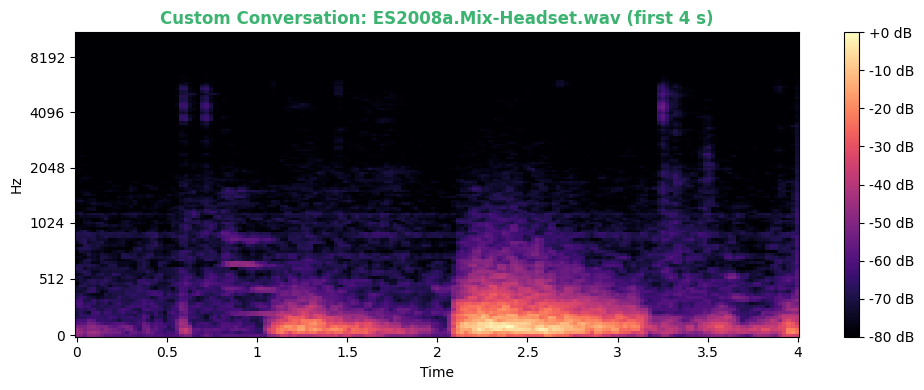

In [7]:
# Show a mel spectrogram snippet from the custom conversation recording
conv_fp = os.path.join(CUSTOM_CONV_PATH, conv_files[0])
audio_conv, sr_conv = load_audio(conv_fp, sample_rate=SAMPLE_RATE, duration=4.0)
mel_conv = librosa.feature.melspectrogram(y=audio_conv, sr=sr_conv, n_mels=128)
mel_db_conv = librosa.power_to_db(mel_conv, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db_conv, sr=sr_conv, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Custom Conversation: {conv_files[0]} (first 4 s)', color='mediumseagreen', fontweight='bold')
plt.tight_layout()
plt.show()